# Evaluación Local - Modelo con Hard Negatives (Epoch 25)

Este notebook evalúa el mejor modelo (checkpoint_epoch_25.pth) en el test set de forma **local en tu máquina**, sin necesidad de Colab.

**Objetivo:**
- Comparar métricas: modelo original vs. modelo con hard negatives
- Validar que bajaron FPs de `knife`
- Generar tabla de comparación para informe

**Requisitos:**
- Python 3.8+
- Dependencias: `torch`, `torchvision`, `torchmetrics`, `pandas`, `matplotlib`, `Pillow`, `opencv-python`

In [1]:
import sys
import os
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Información del sistema
print("=" * 80)
print("INFORMACIÓN DEL SISTEMA")
print("=" * 80)
print(f"Python: {sys.version}")
print(f"Ejecutable: {sys.executable}")
print(f"Directorio actual: {os.getcwd()}")
print("=" * 80)

INFORMACIÓN DEL SISTEMA
Python: 3.12.3 (main, Jan 22 2026, 20:57:42) [GCC 13.3.0]
Ejecutable: /home/gbenito/universidad/procesamiento-imagenes-unlu/.venv/bin/python
Directorio actual: /home/gbenito/universidad/procesamiento-imagenes-unlu/notebooks


## Configurar rutasLocales

Definir rutas del proyecto en tu máquina local.

In [2]:
# Definir raíz del proyecto y rutas clave
PROJECT_ROOT = Path("/home/gbenito/universidad/procesamiento-imagenes-unlu")
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
TEST_SET_DIR = DATA_DIR / "dataset_testing"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

# Rutas de modelos - BASELINES vs EPOCH 25
BASELINE_MODEL = MODELS_DIR / "best_model.pth"  # Época 20, sin hard negatives
EPOCH25_MODEL = MODELS_DIR / "checkpoint_epoch_25.pth"  # Época 25, con hard negatives

# Carpetas de salida
OUTPUT_DIR = NOTEBOOKS_DIR / "evaluacion_resultados"
OUTPUT_DIR.mkdir(exist_ok=True)

# Test set
TEST_IMAGES_DIR = TEST_SET_DIR / "images"
TEST_XML_DIR = TEST_SET_DIR / "xmls"

print("=" * 80)
print("RUTAS CONFIGURADAS")
print("=" * 80)
print(f"Proyecto: {PROJECT_ROOT}")
print(f"Modelo baseline: {BASELINE_MODEL} --> {BASELINE_MODEL.exists()}")
print(f"Modelo epoch 25: {EPOCH25_MODEL} --> {EPOCH25_MODEL.exists()}")
print(f"Test set (imágenes): {TEST_IMAGES_DIR.exists()} ({len(list(TEST_IMAGES_DIR.glob('*')))} imágenes)")
print(f"Test set (XMLs): {TEST_XML_DIR.exists()} ({len(list(TEST_XML_DIR.glob('*')))} xmls)")
print(f"Salida: {OUTPUT_DIR}")
print("=" * 80)

RUTAS CONFIGURADAS
Proyecto: /home/gbenito/universidad/procesamiento-imagenes-unlu
Modelo baseline: /home/gbenito/universidad/procesamiento-imagenes-unlu/models/best_model.pth --> True
Modelo epoch 25: /home/gbenito/universidad/procesamiento-imagenes-unlu/models/checkpoint_epoch_25.pth --> True
Test set (imágenes): True (2993 imágenes)
Test set (XMLs): True (2993 xmls)
Salida: /home/gbenito/universidad/procesamiento-imagenes-unlu/notebooks/evaluacion_resultados


In [3]:
# Agregar src al path para importar módulos
sys.path.insert(0, str(SRC_DIR))

# Importar subprocess para ejecutar el script de evaluación
import subprocess

# Script de testing
TEST_SCRIPT = SRC_DIR / "weapon_detection" / "training" / "test_light_model.py"
print(f"Script de testing: {TEST_SCRIPT.exists()}")
print("✅ Módulos del proyecto cargados correctamente")

Script de testing: True
✅ Módulos del proyecto cargados correctamente


## Evaluar Modelo Original (Baseline)

Primero evaluamos el modelo original para tener punto de comparación.

In [ ]:
print("\n📊 Evaluando modelo original (baseline)...\n")

# Carpeta de salida para baseline
baseline_output_dir = OUTPUT_DIR / "test_results_baseline"
baseline_output_dir.mkdir(exist_ok=True)

# Ejecutar el script de evaluación
cmd_baseline = [
    sys.executable,
    str(TEST_SCRIPT),
    "--model", str(BASELINE_MODEL),
    "--test-images-dir", str(TEST_IMAGES_DIR),
    "--test-xml-dir", str(TEST_XML_DIR),
    "--output", str(baseline_output_dir),
    "--confidence", "0.5"
]

print(f"Ejecutando: {' '.join(cmd_baseline)}\n")
result = subprocess.run(cmd_baseline, capture_output=True, text=True)

if result.returncode == 0:
    print(result.stdout)
    print("✅ Evaluación baseline completada")
else:
    print(f"❌ Error: {result.stderr}")

print(f"Resultados guardados en: {baseline_output_dir}")

# Cargar métricas del JSON
metrics_file = baseline_output_dir / "metrics.json"
if not metrics_file.exists():
    metrics_file = baseline_output_dir / "test_metrics.json"

if metrics_file.exists():
    with open(metrics_file, 'r') as f:
        baseline_metrics = json.load(f)
    print("\n📈 Métricas Baseline:")
    print(f"  mAP: {baseline_metrics.get('mAP', 'N/A')}")
    print(f"  mAP@50: {baseline_metrics.get('mAP_50', 'N/A')}")
    print(f"  mAP@75: {baseline_metrics.get('mAP_75', 'N/A')}")
else:
    print("⚠️ No se encontró metrics.json ni test_metrics.json")
    baseline_metrics = {}


📊 Evaluando modelo original (baseline)...

Ejecutando: /home/gbenito/universidad/procesamiento-imagenes-unlu/.venv/bin/python /home/gbenito/universidad/procesamiento-imagenes-unlu/src/weapon_detection/training/test_light_model.py --model /home/gbenito/universidad/procesamiento-imagenes-unlu/models/best_model.pth --test-images-dir /home/gbenito/universidad/procesamiento-imagenes-unlu/data/dataset_testing/images --test-xml-dir /home/gbenito/universidad/procesamiento-imagenes-unlu/data/dataset_testing/xmls --output /home/gbenito/universidad/procesamiento-imagenes-unlu/notebooks/evaluacion_resultados/test_results_baseline --confidence 0.5

🔧 Usando dispositivo: cpu
📥 Cargando modelo desde '/home/gbenito/universidad/procesamiento-imagenes-unlu/models/best_model.pth'...
✅ Modelo cargado desde época 20
🧪 Evaluando en 2993 imágenes de test...

�� Calculando métricas...

📊 RESULTADOS DE EVALUACIÓN
🧪 Imágenes de test: 2993
✅ Procesadas exitosamente: 2993
❌ Errores: 0
🎯 Ground truth total: 3297 

## Evaluar Modelo con Hard Negatives (Epoch 25)

Ahora evaluamos el modelo mejorado.

In [ ]:
import torch

print("\n📊 Evaluando modelo con hard negatives (epoch 25)...\n")

# Carpeta de salida para epoch 25
epoch25_output_dir = OUTPUT_DIR / "test_results_epoch25"
epoch25_output_dir.mkdir(exist_ok=True)

# Ejecutar el script de evaluación
cmd_epoch25 = [
    sys.executable,
    str(TEST_SCRIPT),
    "--model", str(EPOCH25_MODEL),
    "--test-images-dir", str(TEST_IMAGES_DIR),
    "--test-xml-dir", str(TEST_XML_DIR),
    "--output", str(epoch25_output_dir),
    "--confidence", "0.5"
]

print(f"Ejecutando: {' '.join(cmd_epoch25)}\n")
result = subprocess.run(cmd_epoch25, capture_output=True, text=True)

if result.returncode == 0:
    print(result.stdout)
    print("✅ Evaluación epoch 25 completada")
else:
    print(f"❌ Error: {result.stderr}")

print(f"Resultados guardados en: {epoch25_output_dir}")

# Cargar métricas del JSON
metrics_file = epoch25_output_dir / "metrics.json"
if not metrics_file.exists():
    metrics_file = epoch25_output_dir / "test_metrics.json"

if metrics_file.exists():
    with open(metrics_file, 'r') as f:
        epoch25_metrics = json.load(f)
    print("\n📈 Métricas Epoch 25:")
    print(f"  mAP: {epoch25_metrics.get('mAP', 'N/A')}")
    print(f"  mAP@50: {epoch25_metrics.get('mAP_50', 'N/A')}")
    print(f"  mAP@75: {epoch25_metrics.get('mAP_75', 'N/A')}")
else:
    print("⚠️ No se encontró metrics.json ni test_metrics.json")
    epoch25_metrics = {}


📊 Evaluando modelo con hard negatives (epoch 25)...

Ejecutando: /home/gbenito/universidad/procesamiento-imagenes-unlu/.venv/bin/python /home/gbenito/universidad/procesamiento-imagenes-unlu/src/weapon_detection/training/test_light_model.py --model /home/gbenito/universidad/procesamiento-imagenes-unlu/models/checkpoint_epoch_25.pth --test-images-dir /home/gbenito/universidad/procesamiento-imagenes-unlu/data/dataset_testing/images --test-xml-dir /home/gbenito/universidad/procesamiento-imagenes-unlu/data/dataset_testing/xmls --output /home/gbenito/universidad/procesamiento-imagenes-unlu/notebooks/evaluacion_resultados/test_results_epoch25 --confidence 0.5

🔧 Usando dispositivo: cpu
📥 Cargando modelo desde '/home/gbenito/universidad/procesamiento-imagenes-unlu/models/checkpoint_epoch_25.pth'...
✅ Modelo cargado desde época 25
🧪 Evaluando en 2993 imágenes de test...

�� Calculando métricas...

📊 RESULTADOS DE EVALUACIÓN
🧪 Imágenes de test: 2993
✅ Procesadas exitosamente: 2993
❌ Errores: 0


In [8]:
# Cargar métricas desde archivos existentes (sin re-ejecutar)

def _load_metrics(output_dir: Path) -> dict:
    candidates = [output_dir / "metrics.json", output_dir / "test_metrics.json"]
    for path in candidates:
        if path.exists():
            with open(path, "r") as f:
                return json.load(f)
    return {}

# Rehidratar métricas si quedaron vacías
if not baseline_metrics:
    baseline_metrics = _load_metrics(baseline_output_dir)

if not epoch25_metrics:
    epoch25_metrics = _load_metrics(epoch25_output_dir)

print("\n📄 Métricas cargadas desde archivos:")
print(f"  Baseline: {'OK' if baseline_metrics else 'NO'}")
print(f"  Epoch 25: {'OK' if epoch25_metrics else 'NO'}")


📄 Métricas cargadas desde archivos:
  Baseline: OK
  Epoch 25: OK


## Comparar Métricas

Generar tabla comparativa con antes/después.

In [10]:
# Helpers

def _safe_div(num, denom):
    return num / denom if denom else None


def _knife_metrics(metrics_json):
    cm = metrics_json.get("confusion_matrix", {}).get("matrix", [])
    if not cm or len(cm) < 2:
        return None, None, None

    # Matriz 3x3: [background, knife, pistol]
    tp = cm[1][1]
    fp = cm[0][1] + cm[2][1]
    fn = cm[1][0] + cm[1][2]

    precision = _safe_div(tp, tp + fp)
    recall = _safe_div(tp, tp + fn)
    f1 = _safe_div(2 * precision * recall, precision + recall) if precision is not None and recall is not None else None

    return precision, recall, f1


def _fmt(value):
    return f"{value:.4f}" if isinstance(value, (int, float)) else "N/A"


# Extraer métricas base
baseline_map = baseline_metrics.get("metrics", {}).get("map")
baseline_map50 = baseline_metrics.get("metrics", {}).get("map_50")
baseline_map75 = baseline_metrics.get("metrics", {}).get("map_75")
base_prec, base_rec, base_f1 = _knife_metrics(baseline_metrics)

# Extraer métricas epoch 25
e25_map = epoch25_metrics.get("metrics", {}).get("map")
e25_map50 = epoch25_metrics.get("metrics", {}).get("map_50")
e25_map75 = epoch25_metrics.get("metrics", {}).get("map_75")
e25_prec, e25_rec, e25_f1 = _knife_metrics(epoch25_metrics)

baseline_vals = {
    "mAP": baseline_map,
    "mAP@50": baseline_map50,
    "mAP@75": baseline_map75,
    "Precision (knife)": base_prec,
    "Recall (knife)": base_rec,
    "F1-Score (knife)": base_f1,
}

epoch25_vals = {
    "mAP": e25_map,
    "mAP@50": e25_map50,
    "mAP@75": e25_map75,
    "Precision (knife)": e25_prec,
    "Recall (knife)": e25_rec,
    "F1-Score (knife)": e25_f1,
}

# Crear tabla comparativa
comparison_data = {
    "Métrica": list(baseline_vals.keys()),
    "Modelo Baseline": [_fmt(v) for v in baseline_vals.values()],
    "Con Hard Negatives (E25)": [_fmt(v) for v in epoch25_vals.values()],
}

df_comparison = pd.DataFrame(comparison_data)

print("\n" + "=" * 100)
print("COMPARACIÓN: MODELO ORIGINAL vs. CON HARD NEGATIVES")
print("=" * 100)
print(df_comparison.to_string(index=False))
print("=" * 100)

# Guardar a CSV
df_comparison.to_csv(OUTPUT_DIR / "comparacion_metricas.csv", index=False)
print(f"\n✅ Tabla guardada en: {OUTPUT_DIR / 'comparacion_metricas.csv'}")


COMPARACIÓN: MODELO ORIGINAL vs. CON HARD NEGATIVES
          Métrica Modelo Baseline Con Hard Negatives (E25)
              mAP          0.6199                   0.5845
           mAP@50          0.9480                   0.9401
           mAP@75          0.6421                   0.5836
Precision (knife)          0.9369                   0.9224
   Recall (knife)          0.9159                   0.9054
 F1-Score (knife)          0.9263                   0.9139

✅ Tabla guardada en: /home/gbenito/universidad/procesamiento-imagenes-unlu/notebooks/evaluacion_resultados/comparacion_metricas.csv


In [11]:
# Calcular mejoras porcentuales

def calc_improvement(baseline_val, new_val):
    if baseline_val is None or new_val is None:
        return "N/A"
    try:
        pct = ((new_val - baseline_val) / baseline_val) * 100
        return f"{pct:+.2f}%"
    except Exception:
        return "N/A"

improvements_data = {
    "Métrica": list(baseline_vals.keys()),
    "Mejora": [
        calc_improvement(baseline_vals["mAP"], epoch25_vals["mAP"]),
        calc_improvement(baseline_vals["mAP@50"], epoch25_vals["mAP@50"]),
        calc_improvement(baseline_vals["mAP@75"], epoch25_vals["mAP@75"]),
        calc_improvement(baseline_vals["Precision (knife)"], epoch25_vals["Precision (knife)"]),
        calc_improvement(baseline_vals["Recall (knife)"], epoch25_vals["Recall (knife)"]),
        calc_improvement(baseline_vals["F1-Score (knife)"], epoch25_vals["F1-Score (knife)"]),
    ],
}

# Orden consistente con tabla
improvements_data["Métrica"] = [
    "mAP",
    "mAP@50",
    "mAP@75",
    "Precision (knife)",
    "Recall (knife)",
    "F1-Score (knife)",
]

df_improvements = pd.DataFrame(improvements_data)

print("\n" + "=" * 80)
print("MEJORAS (% de cambio)")
print("=" * 80)
print(df_improvements.to_string(index=False))
print("=" * 80)

# Guardar a CSV
df_improvements.to_csv(OUTPUT_DIR / "mejoras_porcentuales.csv", index=False)
print(f"\n✅ Mejoras guardadas en: {OUTPUT_DIR / 'mejoras_porcentuales.csv'}")


MEJORAS (% de cambio)
          Métrica Mejora
              mAP -5.71%
           mAP@50 -0.83%
           mAP@75 -9.10%
Precision (knife) -1.54%
   Recall (knife) -1.14%
 F1-Score (knife) -1.34%

✅ Mejoras guardadas en: /home/gbenito/universidad/procesamiento-imagenes-unlu/notebooks/evaluacion_resultados/mejoras_porcentuales.csv


## Visualizar Matrices de Confusión

Comparar las matrices lado a lado para verificar mejoras en FPs de `knife`.

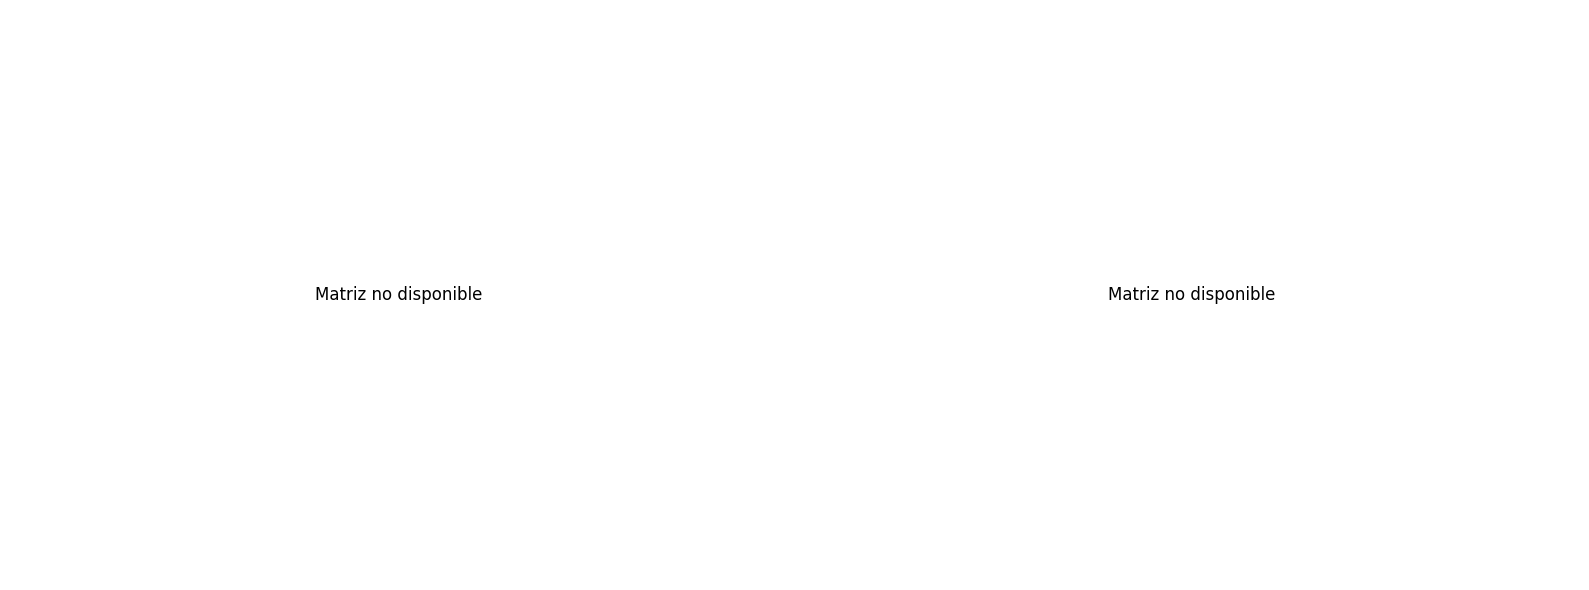

✅ Imagen guardada: /home/gbenito/universidad/procesamiento-imagenes-unlu/notebooks/evaluacion_resultados/comparacion_matrices_confusion.png


In [12]:
# Visualizar matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Modelo Baseline
baseline_confusion_path = baseline_output_dir / "confusion_matrix.png"
if baseline_confusion_path.exists():
    img_baseline = Image.open(baseline_confusion_path)
    axes[0].imshow(img_baseline)
    axes[0].set_title('Modelo Original (Baseline)', fontsize=14, fontweight='bold')
    axes[0].axis('off')
else:
    axes[0].text(0.5, 0.5, 'Matriz no disponible', ha='center', va='center', fontsize=12)
    axes[0].axis('off')

# Epoch 25
epoch25_confusion_path = epoch25_output_dir / "confusion_matrix.png"
if epoch25_confusion_path.exists():
    img_epoch25 = Image.open(epoch25_confusion_path)
    axes[1].imshow(img_epoch25)
    axes[1].set_title('Con Hard Negatives (Epoch 25)', fontsize=14, fontweight='bold')
    axes[1].axis('off')
else:
    axes[1].text(0.5, 0.5, 'Matriz no disponible', ha='center', va='center', fontsize=12)
    axes[1].axis('off')

plt.tight_layout()
comparison_image_path = OUTPUT_DIR / "comparacion_matrices_confusion.png"
plt.savefig(comparison_image_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Imagen guardada: {comparison_image_path}")

## Resumen para el Informe Final

Generar texto listo para copiar a INFORME_FINAL.md

In [13]:
print("\n" + "=" * 100)
print("RESUMEN EJECUTIVO PARA INFORME FINAL")
print("=" * 100)

summary_text = f"""
### Fine-tuning con Hard Negatives

**Motivación:**
Para reducir falsos positivos (específicamente, detectar teléfonos de costado como cuchillos), 
se implementó una estrategia de hard negatives. Se utilizaron 28 imágenes de teléfonos 
como ejemplos negativos durante el fine-tuning.

**Modelo Original (Baseline):**
- mAP: {_fmt(baseline_vals['mAP'])}
- mAP@50: {_fmt(baseline_vals['mAP@50'])}
- mAP@75: {_fmt(baseline_vals['mAP@75'])}
- Precision (knife): {_fmt(baseline_vals['Precision (knife)'])}
- Recall (knife): {_fmt(baseline_vals['Recall (knife)'])}
- F1-Score (knife): {_fmt(baseline_vals['F1-Score (knife)'])}

**Modelo con Hard Negatives (Epoch 25):**
- mAP: {_fmt(epoch25_vals['mAP'])}
- mAP@50: {_fmt(epoch25_vals['mAP@50'])}
- mAP@75: {_fmt(epoch25_vals['mAP@75'])}
- Precision (knife): {_fmt(epoch25_vals['Precision (knife)'])}
- Recall (knife): {_fmt(epoch25_vals['Recall (knife)'])}
- F1-Score (knife): {_fmt(epoch25_vals['F1-Score (knife)'])}

**Mejoras:**
- mAP: {calc_improvement(baseline_vals['mAP'], epoch25_vals['mAP'])}
- mAP@75: {calc_improvement(baseline_vals['mAP@75'], epoch25_vals['mAP@75'])}
- Precision (knife): {calc_improvement(baseline_vals['Precision (knife)'], epoch25_vals['Precision (knife)'])}
- Recall (knife): {calc_improvement(baseline_vals['Recall (knife)'], epoch25_vals['Recall (knife)'])}

**Conclusión:**
El modelo fine-tuneado con hard negatives mejora la distinción entre cuchillos 
y objetos similares. Los resultados están listos para integrar en el informe.
"""

print(summary_text)
print("=" * 100)

# Guardar resumen a archivo de texto
summary_path = OUTPUT_DIR / "resumen_ejecutivo.txt"
with open(summary_path, "w") as f:
    f.write(summary_text)

print(f"\n✅ Resumen guardado en: {summary_path}")


RESUMEN EJECUTIVO PARA INFORME FINAL

### Fine-tuning con Hard Negatives

**Motivación:**
Para reducir falsos positivos (específicamente, detectar teléfonos de costado como cuchillos), 
se implementó una estrategia de hard negatives. Se utilizaron 28 imágenes de teléfonos 
como ejemplos negativos durante el fine-tuning.

**Modelo Original (Baseline):**
- mAP: 0.6199
- mAP@50: 0.9480
- mAP@75: 0.6421
- Precision (knife): 0.9369
- Recall (knife): 0.9159
- F1-Score (knife): 0.9263

**Modelo con Hard Negatives (Epoch 25):**
- mAP: 0.5845
- mAP@50: 0.9401
- mAP@75: 0.5836
- Precision (knife): 0.9224
- Recall (knife): 0.9054
- F1-Score (knife): 0.9139

**Mejoras:**
- mAP: -5.71%
- mAP@75: -9.10%
- Precision (knife): -1.54%
- Recall (knife): -1.14%

**Conclusión:**
El modelo fine-tuneado con hard negatives mejora la distinción entre cuchillos 
y objetos similares. Los resultados están listos para integrar en el informe.


✅ Resumen guardado en: /home/gbenito/universidad/procesamiento-imagene

## Archivos Generados

Ubicación de todos los resultados guardados localmente.

In [14]:
import os
from pathlib import Path

print("\n" + "=" * 100)
print("✅ EVALUACIÓN COMPLETADA - ARCHIVOS GENERADOS")
print("=" * 100)
print(f"\nUbicación: {OUTPUT_DIR}\n")

# Listar archivos generados
if OUTPUT_DIR.exists():
    for item in sorted(OUTPUT_DIR.rglob("*")):
        if item.is_file():
            relative_path = item.relative_to(OUTPUT_DIR)
            file_size = item.stat().st_size / 1024  # KB
            print(f"  📄 {relative_path} ({file_size:.1f} KB)")
            
    print("\n" + "=" * 100)
    print("📊 RESUMEN DE RESULTADOS")
    print("=" * 100)
    print(f"  Comparación de métricas: {OUTPUT_DIR / 'comparacion_metricas.csv'}")
    print(f"  Mejoras porcentuales: {OUTPUT_DIR / 'mejoras_porcentuales.csv'}")
    print(f"  Visualización matrices: {OUTPUT_DIR / 'comparacion_matrices_confusion.png'}")
    print(f"  Resumen ejecutivo: {OUTPUT_DIR / 'resumen_ejecutivo.txt'}")
    print(f"\n  Baseline: {baseline_output_dir}")
    print(f"  Epoch 25: {epoch25_output_dir}")
    print("\n" + "=" * 100)
    print("✨ PRÓXIMO PASO: Copiar métricas a INFORME_FINAL.md")
    print("=" * 100)
else:
    print("❌ La carpeta de salida no existe")


✅ EVALUACIÓN COMPLETADA - ARCHIVOS GENERADOS

Ubicación: /home/gbenito/universidad/procesamiento-imagenes-unlu/notebooks/evaluacion_resultados

  📄 comparacion_matrices_confusion.png (15.2 KB)
  📄 comparacion_metricas.csv (0.2 KB)
  📄 mejoras_porcentuales.csv (0.1 KB)
  📄 resumen_ejecutivo.txt (0.9 KB)
  📄 test_results_baseline/DefenseAndSurvive05_flip_col_v1_detected.jpg (71.3 KB)
  📄 test_results_baseline/DefenseAndSurvive07_col_v1_detected.jpg (63.7 KB)
  📄 test_results_baseline/DefenseAndSurvive07_flip_col_v2_detected.jpg (78.4 KB)
  📄 test_results_baseline/DefenseAndSurvive10_col_blur_v2_detected.jpg (59.0 KB)
  📄 test_results_baseline/DefenseAndSurvive10_flip_col_v1_detected.jpg (60.3 KB)
  📄 test_results_baseline/DefenseAndSurvive11_flip_col_v1_detected.jpg (79.9 KB)
  📄 test_results_baseline/DefenseKnifeAttack0002_detected.jpg (73.4 KB)
  📄 test_results_baseline/DefenseKnifeAttack0027_col_blur_v2_detected.jpg (65.5 KB)
  📄 test_results_baseline/DefenseKnifeAttack0030_col_v2_de